
# 04_temporalAA_TRANSPOSED_topm_gif_visualization.ipynb

Small add-on notebook for the corrected **Temporal AA** pipeline.

In this orientation:
- `sXC`: **V x K** spatial motifs
- `S`: **K x T** timecourse coefficients

This notebook:
- loads the decoding-ranked top-m archetypes
- uses each archetype's **spatial motif** `sXC[:, k]`
- changes opacity over time using the **timecourse coefficient** `S[k, t]`
- plots the matching coefficient lines underneath
- can export frames for a GIF


In [12]:

%matplotlib inline
import os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

try:
    from nilearn import plotting as niplot
    NILEARN_AVAILABLE = True
except Exception:
    NILEARN_AVAILABLE = False
    print("nilearn not available; brain plotting disabled.")
print("Ready.")


Ready.


In [13]:

LOAD_DIR = "temporalAA_transposed_outputs_npz"
RANKING_DIR = "temporalAA_TRANSPOSED_decoding_summaries"
K_TO_USE = 25
TOP_M = 3
SUBJECT_INDEX = 0
USE_CONDITION_AVERAGE = False
CONDITION_TO_AVERAGE = "intact"

EXPORT_FRAMES = False
FRAME_STEP = 5
MAX_FRAMES = None
FPS = 8

OUTPUT_DIR = "temporalAA_TRANSPOSED_gif_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [14]:

def load_msaa_npz(path):
    data = np.load(path, allow_pickle=True)
    results_subj = data["results_subj"].tolist()
    if isinstance(results_subj, np.ndarray):
        results_subj = results_subj.tolist()
    return {
        "K": int(data["K"]),
        "results_subj": results_subj,
        "condition_labels_str": data["condition_labels_str"].tolist(),
        "condition_codes": data["condition_codes"],
        "centers": np.array(data["centers"]) if "centers" in data else None,
    }

cur = load_msaa_npz(os.path.join(LOAD_DIR, f"temporalAA_TRANSPOSED_acrossCond_K{K_TO_USE}.npz"))
condition_labels_str = np.array(cur["condition_labels_str"])
rankings_path = os.path.join(RANKING_DIR, "global_rankings_by_K.npy")
global_rankings = np.load(rankings_path, allow_pickle=True).item()
top_idx = list(global_rankings[K_TO_USE][:TOP_M])
centers = cur["centers"]

if USE_CONDITION_AVERAGE:
    idx = np.where(condition_labels_str == CONDITION_TO_AVERAGE)[0]
    sXC_stack = np.stack([to_float_array(cur["results_subj"][i]["sXC"]) for i in idx], axis=0)
    S_stack = np.stack([to_float_array(cur["results_subj"][i]["S"]) for i in idx], axis=0)
    sXC = sXC_stack.mean(axis=0)   # V x K
    S = S_stack.mean(axis=0)       # K x T
    source_label = f"condition average: {CONDITION_TO_AVERAGE}"
else:
    sub = cur["results_subj"][SUBJECT_INDEX]
    sXC = to_float_array(sub["sXC"])
    S = to_float_array(sub["S"])
    source_label = f"subject {SUBJECT_INDEX}"

top_spatial = sXC[:, top_idx]   # V x m
top_time = S[top_idx, :]        # m x T

DEFAULT_ARCH_COLORS = ["purple", "green", "orange", "deepskyblue", "red", "gold", "brown"]
arch_color_map = {k: DEFAULT_ARCH_COLORS[i % len(DEFAULT_ARCH_COLORS)] for i, k in enumerate(top_idx)}

print("Top archetypes:", top_idx)
print("Source:", source_label)
print("top_spatial shape:", top_spatial.shape, "top_time shape:", top_time.shape)


Top archetypes: [9, 13, 7]
Source: subject 0
top_spatial shape: (700, 3) top_time shape: (3, 300)


In [15]:

def to_float_array(x):
    """Safely coerce arrays loaded from npz/object containers to float ndarrays."""
    return np.array(x, dtype=float)


In [16]:

# Optional quick checks
example_sub = cur["results_subj"][0]
print("sXC dtype:", to_float_array(example_sub["sXC"]).dtype, "shape:", to_float_array(example_sub["sXC"]).shape)
print("S dtype:", to_float_array(example_sub["S"]).dtype, "shape:", to_float_array(example_sub["S"]).shape)
print("condition label dtype:", np.array(condition_labels_str).dtype)


sXC dtype: float64 shape: (700, 25)
S dtype: float64 shape: (25, 300)
condition label dtype: <U6


In [17]:

def normalize_for_opacity(x, eps=1e-8):
    x = np.array(x, dtype=float)
    xabs = np.abs(x)
    return xabs / (xabs.max() + eps)

def get_temporal_frame_components(top_spatial, top_time, t):
    coeff_t = top_time[:, t]
    spatial_abs = np.abs(top_spatial.T)      # m x V
    spatial_norm = spatial_abs / (spatial_abs.max(axis=1, keepdims=True) + 1e-8)
    coeff_norm = normalize_for_opacity(coeff_t)[:, None]
    node_alpha = coeff_norm * spatial_norm
    return coeff_t, node_alpha

def plot_topm_coeff_lines(top_time, top_idx, arch_color_map, t=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 2.8))
    for j, k in enumerate(top_idx):
        ax.plot(top_time[j], color=arch_color_map[k], label=f"arch {k}")
    if t is not None:
        ax.axvline(t, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Time"); ax.set_ylabel("Coeff")
    ax.legend(loc="upper right", ncol=min(len(top_idx), 3), fontsize=8)
    return ax

def plot_brain_overlay_frame(top_idx, node_alpha, arch_color_map, centers, title="", node_size=10):
    if not NILEARN_AVAILABLE:
        print("nilearn not available"); return None, None
    fig = plt.figure(figsize=(7, 5)); display = None
    for j, k in enumerate(top_idx):
        base = to_rgba(arch_color_map[k])
        node_colors = [(base[0], base[1], base[2], float(a)) for a in node_alpha[j]]
        display = niplot.plot_connectome(
            np.eye(centers.shape[0]), centers, node_color=node_colors,
            node_size=node_size, display_mode="lyrz",
            title=title if j == 0 else None, figure=fig
        )
    return fig, display

def make_preview_frame(t, top_spatial, top_time, top_idx, arch_color_map, centers, source_label):
    _, node_alpha = get_temporal_frame_components(top_spatial, top_time, t)
    fig = plt.figure(figsize=(10, 7))
    gs = fig.add_gridspec(2, 1, height_ratios=[3.5, 1.5])

    ax_brain = fig.add_subplot(gs[0]); ax_brain.axis("off")
    plt.sca(ax_brain)
    _, disp = plot_brain_overlay_frame(top_idx, node_alpha, arch_color_map, centers,
                                       title=f"{source_label} | time {t}", node_size=10)

    ax_lines = fig.add_subplot(gs[1])
    plot_topm_coeff_lines(top_time, top_idx, arch_color_map, t=t, ax=ax_lines)
    ax_lines.set_title("Top-m coefficient timecourses")
    plt.tight_layout()
    return fig, disp


/var/folders/4j/wgxcnp1d5kx_wk4b7vtwn_ww0000gn/T/ipykernel_95418/1317947131.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


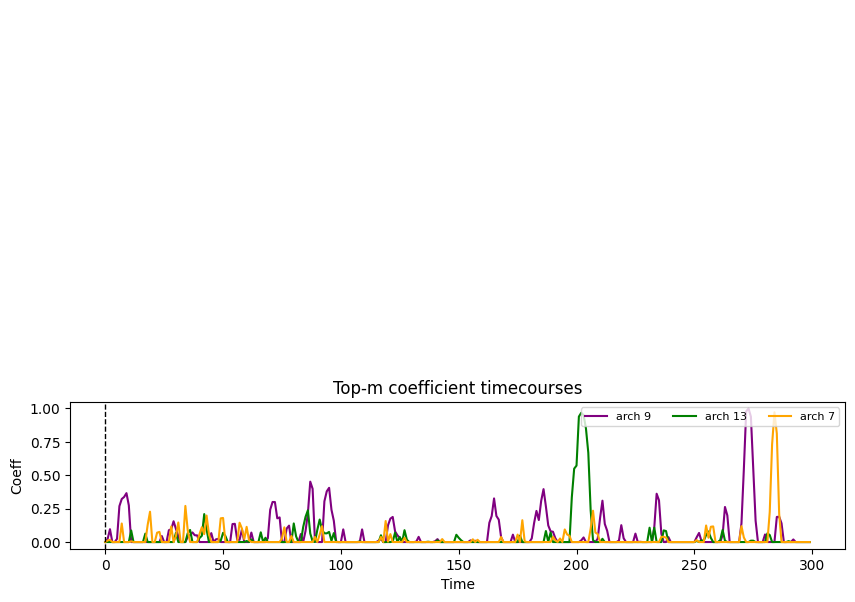

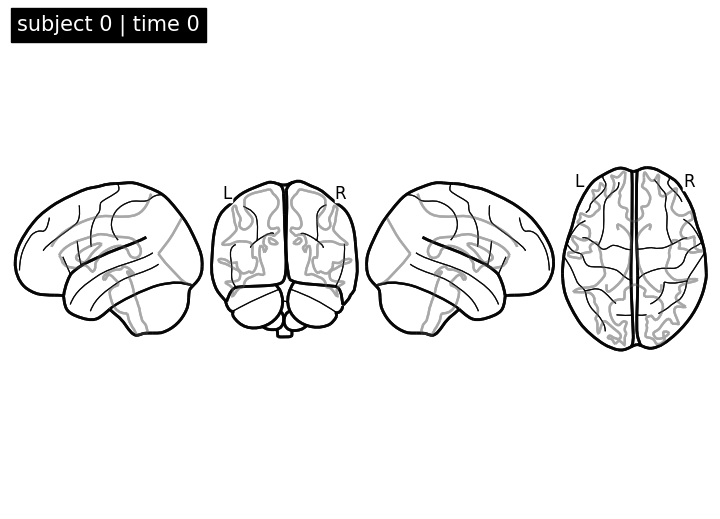

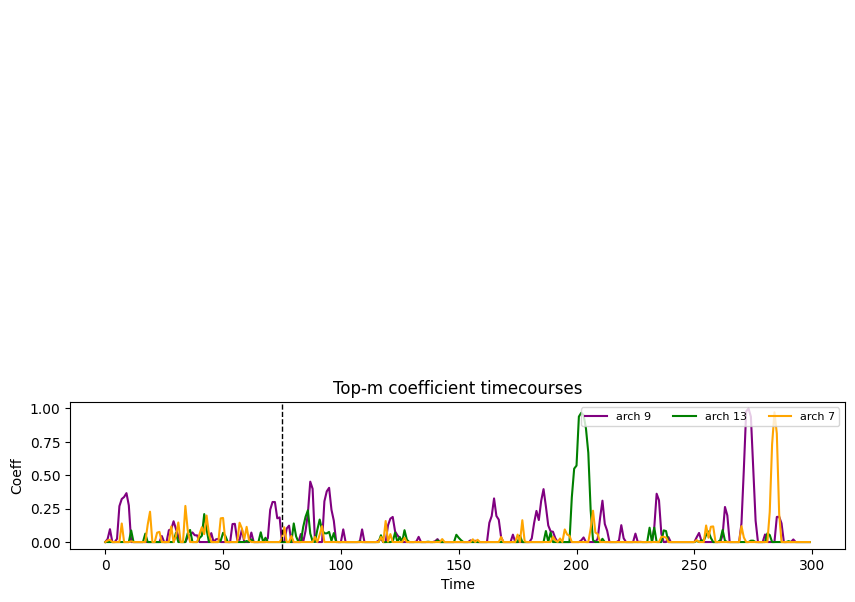

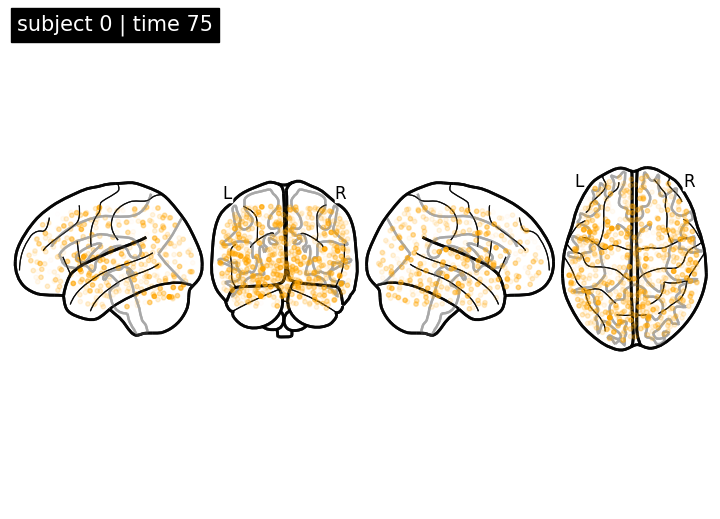

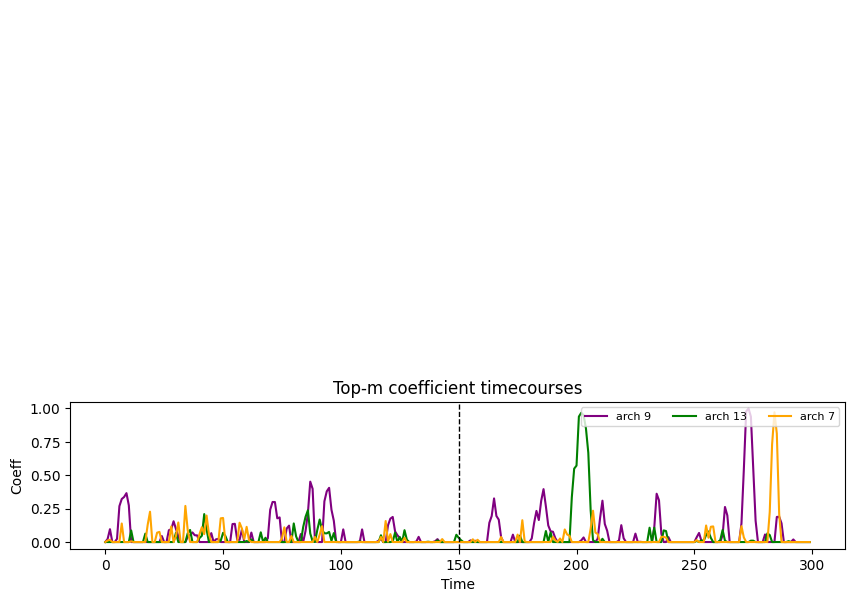

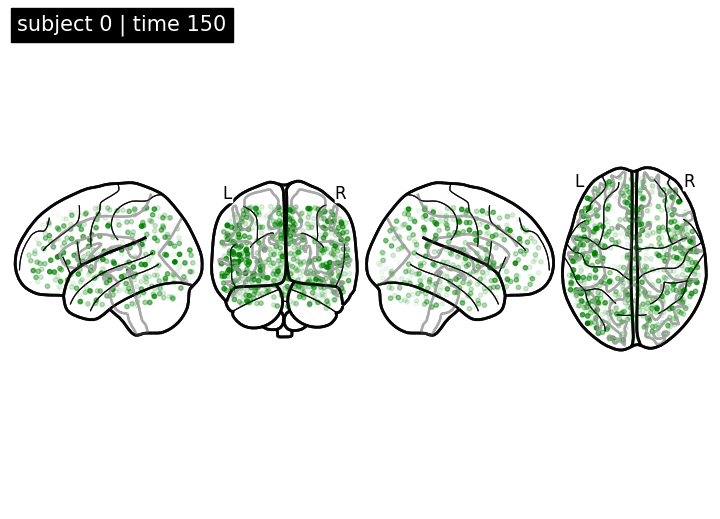

In [18]:

preview_times = [0, top_time.shape[1]//4, top_time.shape[1]//2]
for t in preview_times:
    fig, disp = make_preview_frame(t, top_spatial, top_time, top_idx, arch_color_map, centers, source_label)
    plt.show()
    try:
        disp.close()
    except Exception:
        pass
    plt.close(fig)


In [19]:

frames_dir = os.path.join(
    OUTPUT_DIR,
    f"K{K_TO_USE}_top{TOP_M}_{source_label.replace(' ', '_').replace(':', '')}"
)
os.makedirs(frames_dir, exist_ok=True)

if EXPORT_FRAMES:
    all_times = np.arange(0, top_time.shape[1], FRAME_STEP)
    if MAX_FRAMES is not None:
        all_times = all_times[:MAX_FRAMES]
    print("Saving", len(all_times), "frames to", frames_dir)
    for frame_i, t in enumerate(all_times):
        fig, disp = make_preview_frame(top_spatial=top_spatial, top_time=top_time, top_idx=top_idx,
                                       arch_color_map=arch_color_map, centers=centers, source_label=source_label, t=t)
        out_file = os.path.join(frames_dir, f"frame_{frame_i:04d}.png")
        fig.savefig(out_file, dpi=140, bbox_inches="tight")
        try:
            disp.close()
        except Exception:
            pass
        plt.close(fig)
    print("Finished saving frames.")
else:
    print("EXPORT_FRAMES is False. Set it to True to save frame images.")


EXPORT_FRAMES is False. Set it to True to save frame images.
